# 🩺 Diabetes End-to-End Machine Learning Pipeline

## Project Overview
This notebook walks through a complete ML pipeline on the **PIMA Indians Diabetes Dataset**.

### Steps
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Base Model Comparison
4. Hyperparameter Optimization
5. Voting Classifier (Ensemble)
6. Prediction for New Observations

### Dataset
- 768 patients, 8 original features
- Binary target: `Outcome` (1 = diabetic, 0 = healthy)
- Source: [Kaggle PIMA Diabetes Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [1]:
import sys
sys.path.append("../src")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from helpers import (grab_col_names, check_df, cat_summary, 
                     num_summary, target_summary_with_num, correlation_matrix)
from pipeline import (diabetes_data_prep, base_models, 
                      hyperparameter_optimization, voting_classifier)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Libraries loaded.")

✅ Libraries loaded.


---
## 1. Exploratory Data Analysis (EDA)

In [5]:
df = pd.read_csv("../datasets/diabetes.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


### 1.1 General Overview

In [6]:
check_df(df)

── Shape ──────────────────────────────
(768, 9)
── Types ──────────────────────────────
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
── Head ───────────────────────────────
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
0            6      148             72             35        0 33.600   
1            1       85             66             29        0 26.600   
2            8      183             64              0        0 23.300   
3            1       89             66             23       94 28.100   
4            0      137             40             35      168 43.100   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1     

### 1.2 Missing Value Analysis
> Columns like Glucose, Insulin, BMI cannot be 0 physiologically. 
> These zeros actually represent missing values.

In [7]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_df = pd.DataFrame({
    "Zero Count": [(df[col] == 0).sum() for col in zero_cols],
    "Zero Ratio": [(df[col] == 0).mean() * 100 for col in zero_cols]
}, index=zero_cols)

zero_df["Zero Ratio"] = zero_df["Zero Ratio"].map("{:.1f}%".format)
print(zero_df)

               Zero Count Zero Ratio
Glucose                 5       0.7%
BloodPressure          35       4.6%
SkinThickness         227      29.6%
Insulin               374      48.7%
BMI                    11       1.4%


### 1.3 Target Variable Distribution

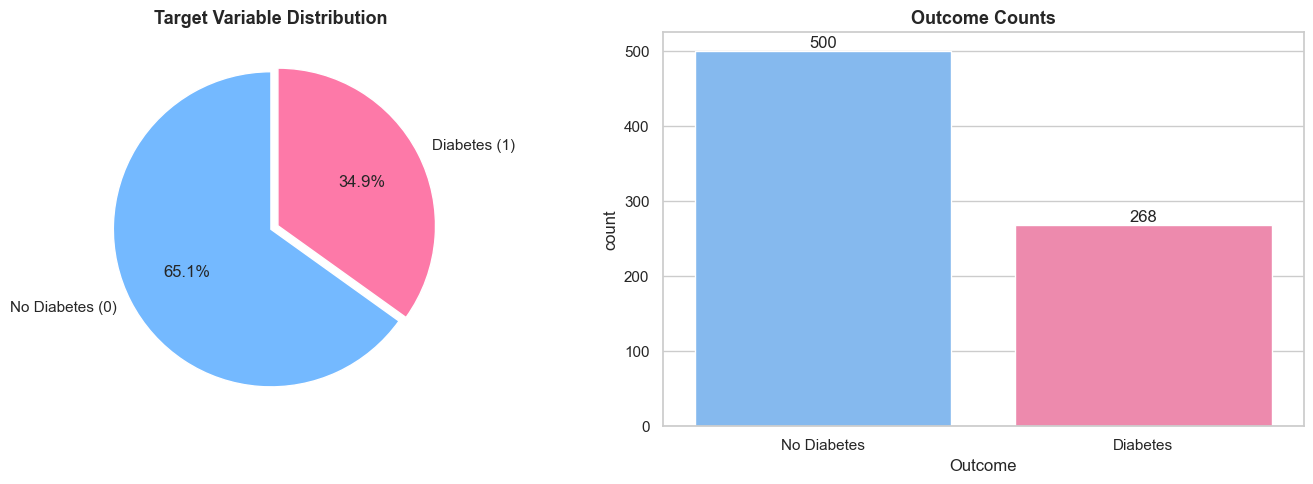

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["Outcome"].value_counts()
axes[0].pie(
    counts,
    labels=["No Diabetes (0)", "Diabetes (1)"],
    autopct="%1.1f%%",
    colors=["#74b9ff", "#fd79a8"],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title("Target Variable Distribution", fontsize=13, fontweight="bold")

sns.countplot(x="Outcome", data=df, ax=axes[1],
              palette=["#74b9ff", "#fd79a8"], edgecolor="white")
axes[1].set_title("Outcome Counts", fontsize=13, fontweight="bold")
axes[1].set_xticklabels(["No Diabetes", "Diabetes"])

for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=12)

plt.tight_layout()
plt.show()

### 1.4 Feature Distributions by Outcome

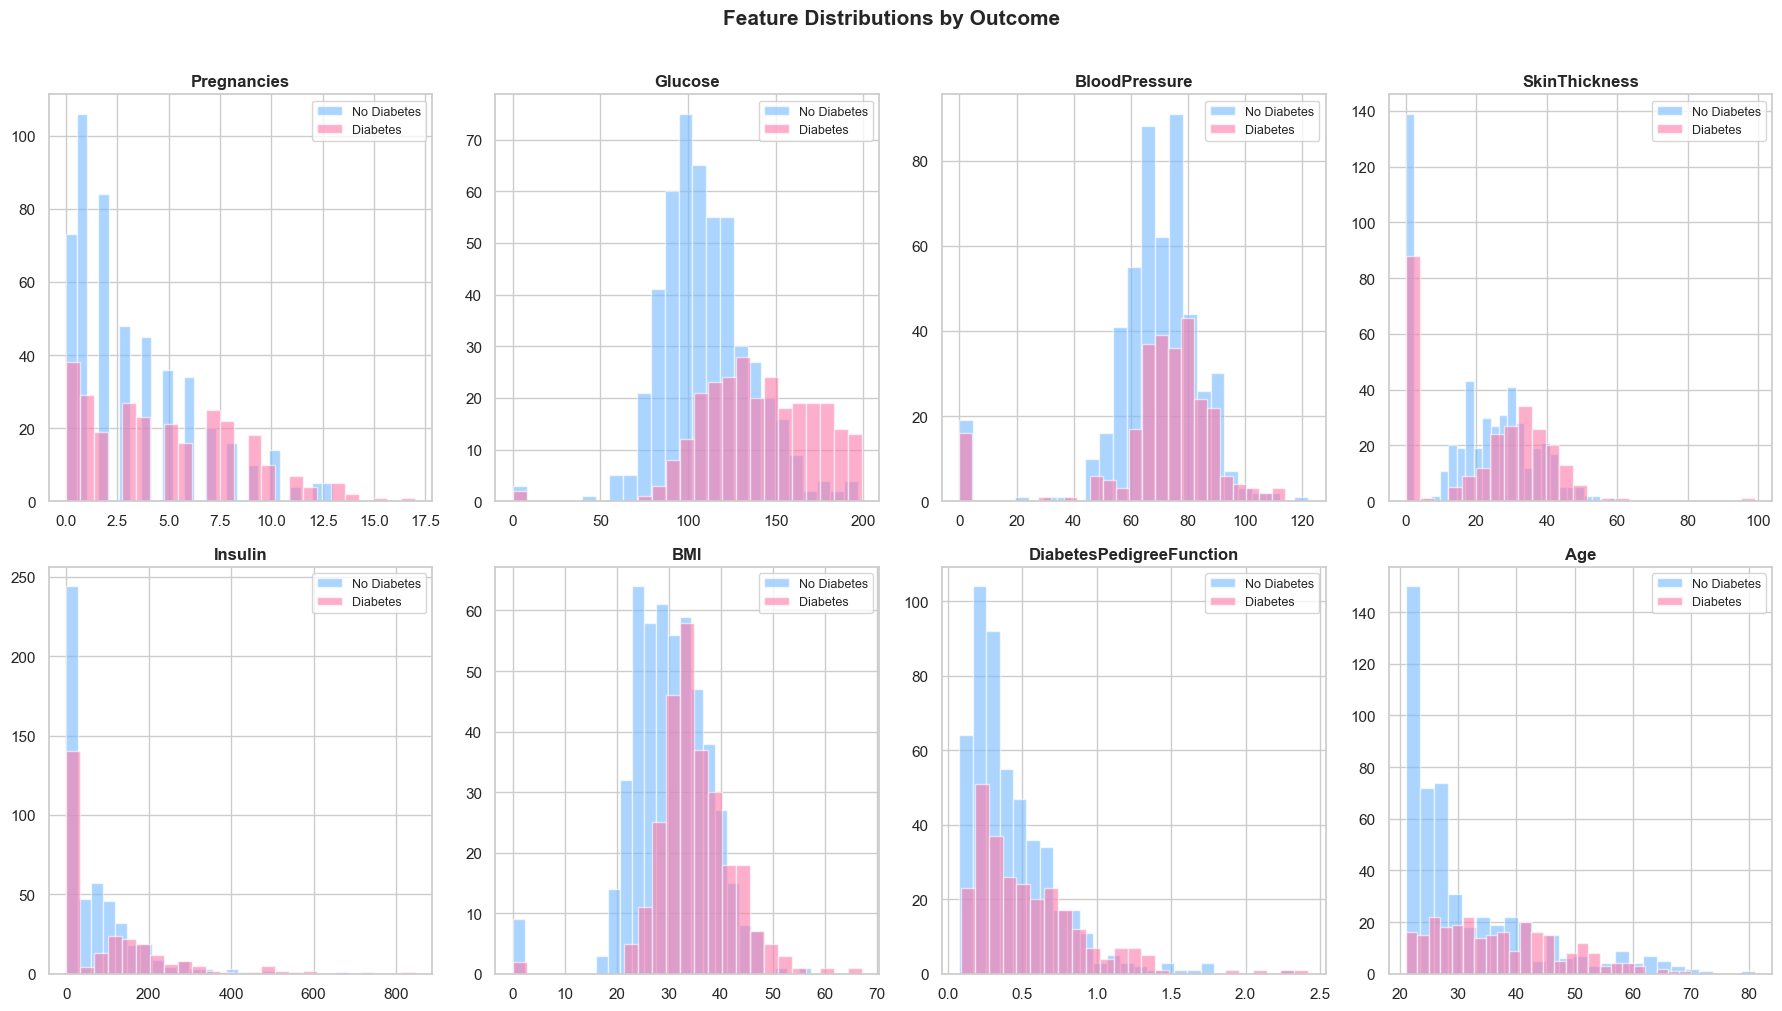

In [9]:
num_features = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    for outcome, color, label in [(0, "#74b9ff", "No Diabetes"),
                                   (1, "#fd79a8", "Diabetes")]:
        axes[i].hist(
            df[df["Outcome"] == outcome][col],
            bins=25, alpha=0.6, color=color,
            label=label, edgecolor="white"
        )
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].legend(fontsize=9)

plt.suptitle("Feature Distributions by Outcome",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix

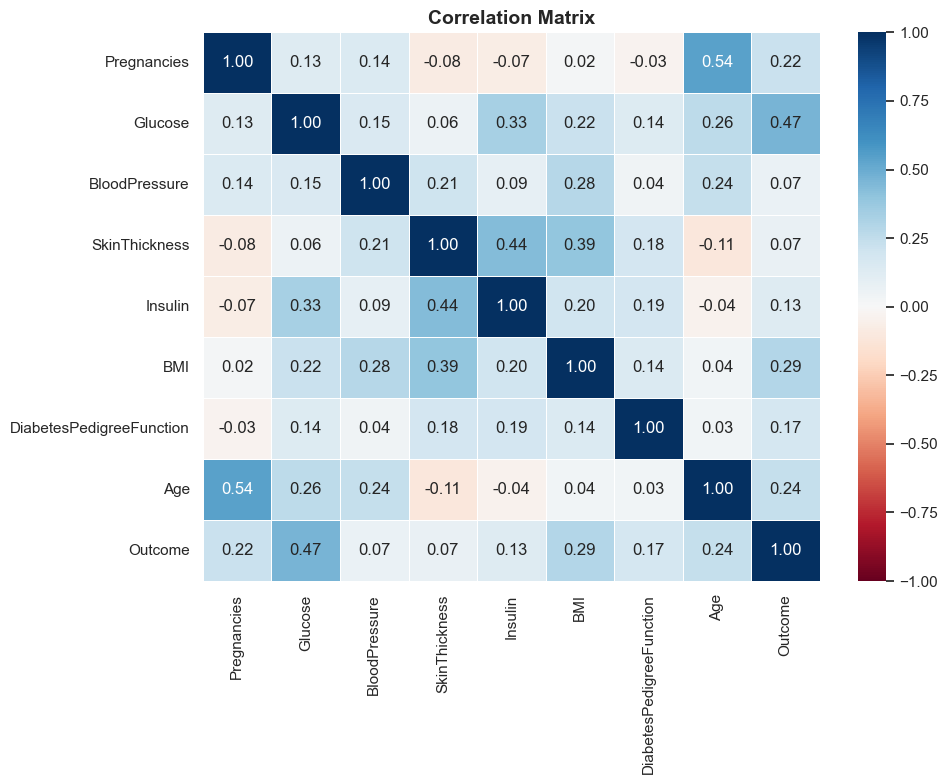

In [10]:
correlation_matrix(df, df.columns.tolist())

### 1.6 Target vs Numerical Features

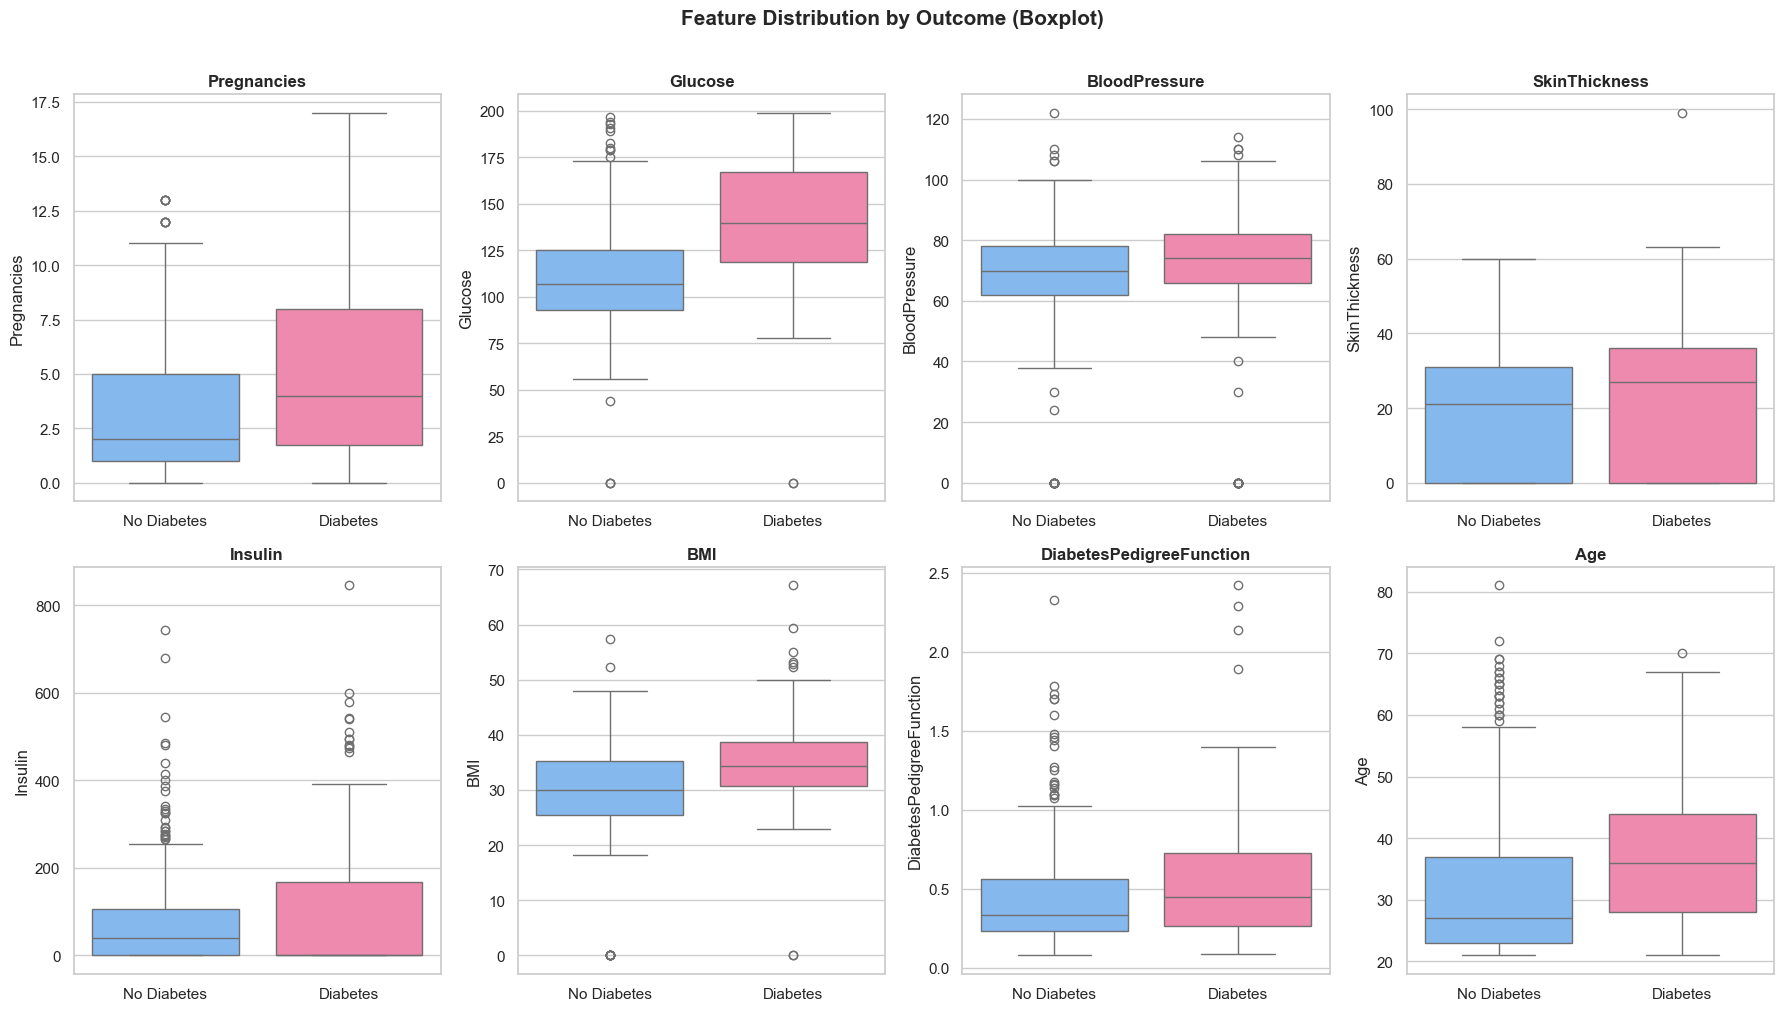

In [11]:
num_features = [c for c in df.columns if c != "Outcome"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i],
                palette=["#74b9ff", "#fd79a8"])
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xticklabels(["No Diabetes", "Diabetes"])
    axes[i].set_xlabel("")

plt.suptitle("Feature Distribution by Outcome (Boxplot)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Data Preprocessing & Feature Engineering

In [12]:
df_raw = pd.read_csv("../datasets/diabetes.csv")
X, y = diabetes_data_prep(df_raw)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nNew features added:")
new_features = [c for c in X.columns if "NEW_" in c]
for f in new_features:
    print(f"  → {f}")

Observations : 768
Variables    : 15
cat_cols     : 5  → ['OUTCOME', 'NEW_GLUCOSE_CAT', 'NEW_AGE_CAT', 'NEW_BMI_RANGE', 'NEW_BLOODPRESSURE']
num_cols     : 10  → ['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN', 'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE', 'NEW_GLUCOSE_BMI', 'NEW_INSULIN_BMI']
cat_but_car  : 0
Observations : 768
Variables    : 19
cat_cols     : 9  → ['OUTCOME', 'NEW_GLUCOSE_CAT_prediabetes', 'NEW_AGE_CAT_middleage', 'NEW_AGE_CAT_old', 'NEW_BMI_RANGE_healthy', 'NEW_BMI_RANGE_overweight', 'NEW_BMI_RANGE_obese', 'NEW_BLOODPRESSURE_hs1', 'NEW_BLOODPRESSURE_hs2']
num_cols     : 10  → ['PREGNANCIES', 'GLUCOSE', 'BLOODPRESSURE', 'SKINTHICKNESS', 'INSULIN', 'BMI', 'DIABETESPEDIGREEFUNCTION', 'AGE', 'NEW_GLUCOSE_BMI', 'NEW_INSULIN_BMI']
cat_but_car  : 0
X shape : (768, 18)
y shape : (768,)

New features added:
  → NEW_GLUCOSE_BMI
  → NEW_INSULIN_BMI
  → NEW_GLUCOSE_CAT_prediabetes
  → NEW_AGE_CAT_middleage
  → NEW_AGE_CAT_old
  → NEW_BMI_RANGE_healthy
  → NEW

### 2.1 Feature Engineering Summary

| Original Feature | New Feature | Description |
|-----------------|-------------|-------------|
| Glucose | NEW_GLUCOSE_CAT | normal / prediabetes |
| Age | NEW_AGE_CAT | young / middleage / old |
| BMI | NEW_BMI_RANGE | underweight / healthy / overweight / obese |
| BloodPressure | NEW_BLOODPRESSURE | normal / hs1 / hs2 |
| Glucose × BMI | NEW_GLUCOSE_BMI | interaction feature |
| Insulin × BMI | NEW_INSULIN_BMI | interaction feature |

In [13]:
print("Final feature matrix:\n")
print(X.head())
print(f"\nData types:\n{X.dtypes}")

Final feature matrix:

   PREGNANCIES  GLUCOSE  BLOODPRESSURE  SKINTHICKNESS  INSULIN    BMI  \
0        0.640    0.865         -0.032          0.674    0.325  0.169   
1       -0.845   -1.205         -0.528         -0.009   -0.450 -0.849   
2        1.234    2.014         -0.693          0.333    0.325 -1.328   
3       -0.845   -1.073         -0.528         -0.692   -0.548 -0.630   
4       -1.142    0.503         -2.677          0.674    0.308  1.551   

   DIABETESPEDIGREEFUNCTION    AGE  NEW_GLUCOSE_BMI  NEW_INSULIN_BMI  \
0                     0.468  1.426            0.663            0.286   
1                    -0.365 -0.191           -1.178           -0.591   
2                     0.604 -0.106            0.182           -0.230   
3                    -0.921 -1.042           -1.015           -0.616   
4                     5.485 -0.020            1.296            0.742   

   NEW_GLUCOSE_CAT_prediabetes  NEW_AGE_CAT_middleage  NEW_AGE_CAT_old  \
0                            1 

---
## 3. Base Model Comparison

In [14]:
base_results = base_models(X, y, scoring="roc_auc")


BASE MODELS
  LR           roc_auc: 0.8669
  KNN          roc_auc: 0.8774
  SVC          roc_auc: 0.9063
  CART         roc_auc: 0.8509
  RF           roc_auc: 0.9422
  AdaBoost     roc_auc: 0.9382
  GBM          roc_auc: 0.9509
  XGBoost      roc_auc: 0.9475
  LightGBM     roc_auc: 0.947


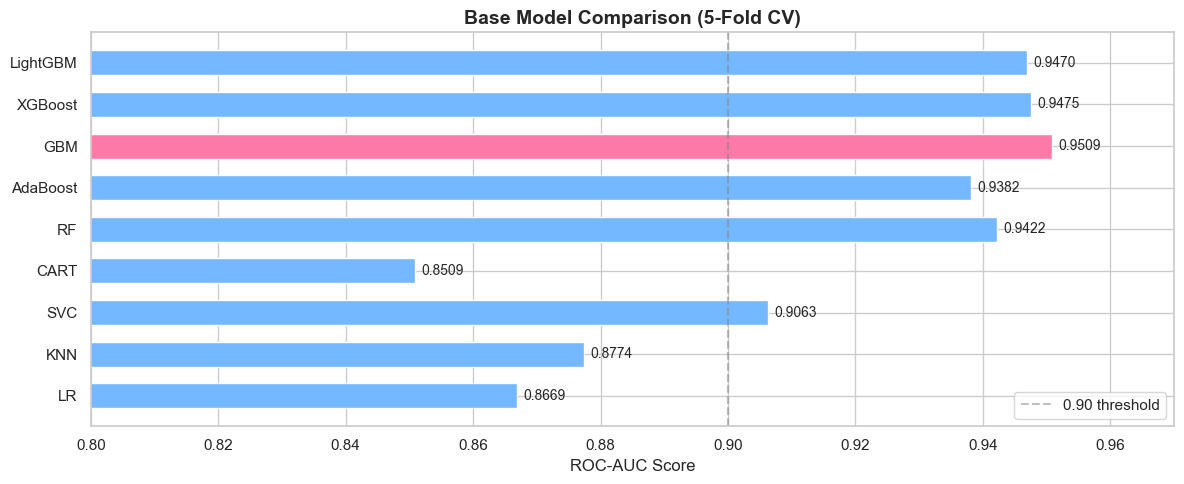

In [15]:
names  = list(base_results.keys())
scores = list(base_results.values())

colors = ["#fd79a8" if s == max(scores) else "#74b9ff" for s in scores]

plt.figure(figsize=(12, 5))
bars = plt.barh(names, scores, color=colors, edgecolor="white", height=0.6)
plt.xlim(0.80, 0.97)
plt.xlabel("ROC-AUC Score", fontsize=12)
plt.title("Base Model Comparison (5-Fold CV)", fontsize=14, fontweight="bold")
plt.axvline(x=0.90, color="gray", linestyle="--", alpha=0.5, label="0.90 threshold")

for bar, score in zip(bars, scores):
    plt.text(score + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{score:.4f}", va="center", fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Hyperparameter Optimization

In [16]:
best_models = hyperparameter_optimization(X, y, cv=5, scoring="roc_auc")


HYPERPARAMETER OPTIMIZATION

── KNN ──────────────────────────────
  roc_auc before: 0.8774
  roc_auc after : 0.8916
  Best params    : {'n_neighbors': 7}

── CART ──────────────────────────────
  roc_auc before: 0.8509
  roc_auc after : 0.9121
  Best params    : {'max_depth': 7, 'min_samples_split': 12}

── RF ──────────────────────────────
  roc_auc before: 0.9422
  roc_auc after : 0.9462
  Best params    : {'max_depth': 8, 'max_features': 7, 'min_samples_split': 20, 'n_estimators': 200}

── XGBoost ──────────────────────────────
  roc_auc before: 0.9475
  roc_auc after : 0.9485
  Best params    : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100}

── LightGBM ──────────────────────────────
  roc_auc before: 0.947
  roc_auc after : 0.9551
  Best params    : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'n_estimators': 300}


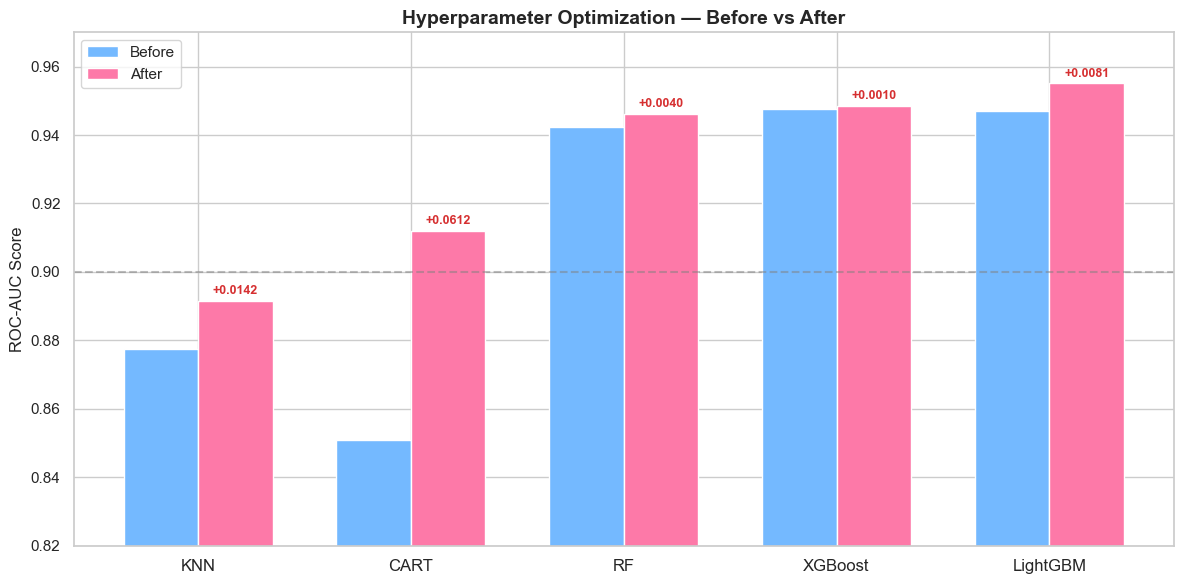

In [17]:
tuning_results = {
    "KNN"     : {"before": 0.8774, "after": 0.8916},
    "CART"    : {"before": 0.8509, "after": 0.9121},
    "RF"      : {"before": 0.9422, "after": 0.9462},
    "XGBoost" : {"before": 0.9475, "after": 0.9485},
    "LightGBM": {"before": 0.9470, "after": 0.9551},
}

names   = list(tuning_results.keys())
befores = [v["before"] for v in tuning_results.values()]
afters  = [v["after"]  for v in tuning_results.values()]
gains   = [round(a - b, 4) for a, b in zip(afters, befores)]

x = range(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], befores, width, label="Before", color="#74b9ff", edgecolor="white")
bars2 = ax.bar([i + width/2 for i in x], afters,  width, label="After",  color="#fd79a8", edgecolor="white")

for bar, gain in zip(bars2, gains):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"+{gain:.4f}", ha="center", va="bottom", fontsize=9, color="#d63031", fontweight="bold")

ax.set_ylim(0.82, 0.97)
ax.set_xticks(list(x))
ax.set_xticklabels(names, fontsize=12)
ax.set_ylabel("ROC-AUC Score", fontsize=12)
ax.set_title("Hyperparameter Optimization — Before vs After", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.axhline(y=0.90, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. Voting Classifier (Ensemble)

In [18]:
voting_clf = voting_classifier(best_models, X, y)


VOTING CLASSIFIER (Ensemble)
  Accuracy : 0.8894
  F1 Score : 0.8396
  ROC-AUC  : 0.9477


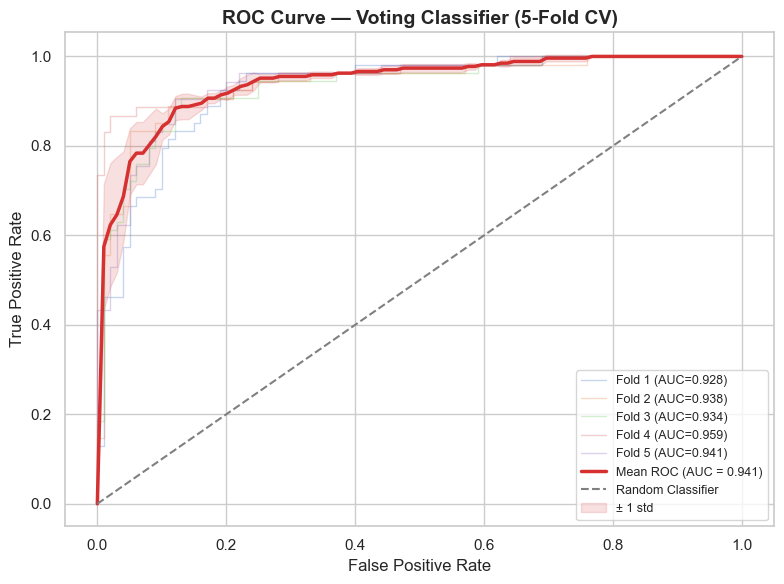

In [19]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs, aucs = [], []
mean_fpr = np.linspace(0, 1, 100)

fig, ax = plt.subplots(figsize=(8, 6))

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    voting_clf.fit(X_train, y_train)
    y_prob = voting_clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(auc(fpr, tpr))
    ax.plot(fpr, tpr, alpha=0.3, lw=1, label=f"Fold {fold+1} (AUC={aucs[-1]:.3f})")

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

ax.plot(mean_fpr, mean_tpr, color="#d63031", lw=2.5,
        label=f"Mean ROC (AUC = {mean_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
ax.fill_between(mean_fpr,
                np.mean(tprs, axis=0) - np.std(tprs, axis=0),
                np.mean(tprs, axis=0) + np.std(tprs, axis=0),
                alpha=0.15, color="#d63031", label="± 1 std")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve — Voting Classifier (5-Fold CV)", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 5.1 Feature Importance

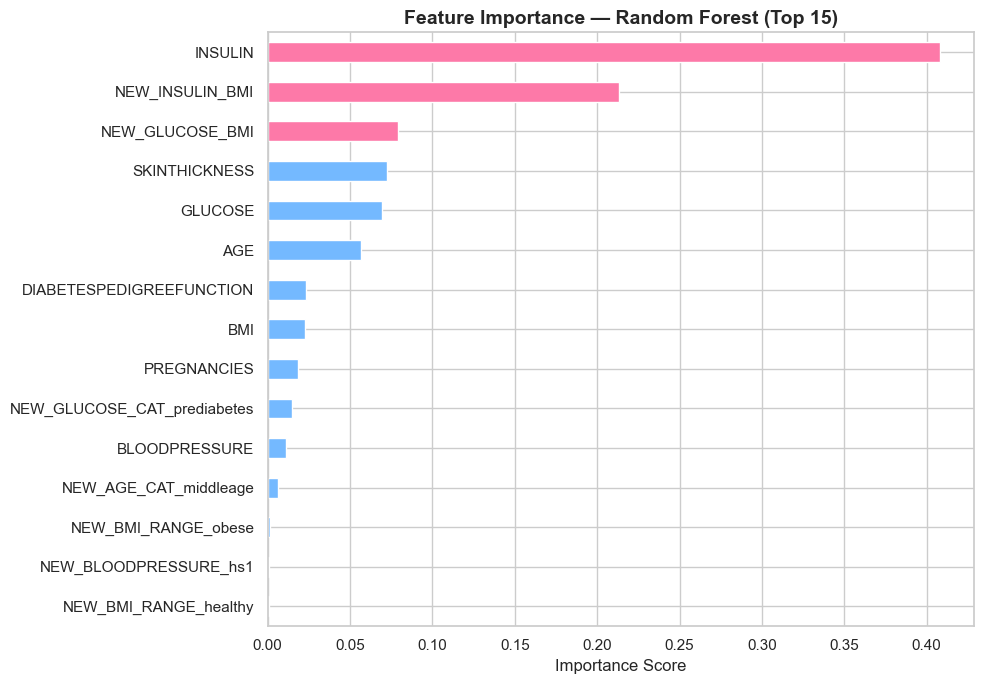

In [20]:
rf_model = best_models["RF"]
rf_model.fit(X, y)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True).tail(15)

colors = ["#fd79a8" if i >= len(importances) - 3 else "#74b9ff"
          for i in range(len(importances))]

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color=colors, edgecolor="white")
plt.title("Feature Importance — Random Forest (Top 15)",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.tight_layout()
plt.show()

---
## 6. Prediction for New Observations

In [21]:
model = joblib.load("../models/voting_clf.pkl")

sample_users = X.sample(5, random_state=42)
predictions  = model.predict(sample_users)
probabilities = model.predict_proba(sample_users)[:, 1]

results = pd.DataFrame({
    "Actual"     : y[sample_users.index].values,
    "Prediction" : predictions,
    "Probability": [f"{p:.1%}" for p in probabilities],
    "Result"     : ["✅ Correct" if a == p else "❌ Wrong"
                    for a, p in zip(y[sample_users.index].values, predictions)]
}, index=sample_users.index)

print("=== Predictions for Sample Patients ===\n")
print(results)

=== Predictions for Sample Patients ===

     Actual  Prediction Probability     Result
668       0           0       40.9%  ✅ Correct
324       0           0        1.8%  ✅ Correct
624       0           0        1.0%  ✅ Correct
690       0           0        1.4%  ✅ Correct
473       0           0       11.1%  ✅ Correct


In [22]:
# Diyabetli hastalardan örnek al
diabetic_samples = X[y == 1].sample(5, random_state=42)
predictions   = model.predict(diabetic_samples)
probabilities = model.predict_proba(diabetic_samples)[:, 1]

results2 = pd.DataFrame({
    "Actual"     : y[diabetic_samples.index].values,
    "Prediction" : predictions,
    "Probability": [f"{p:.1%}" for p in probabilities],
    "Result"     : ["✅ Correct" if a == p else "❌ Wrong"
                    for a, p in zip(y[diabetic_samples.index].values, predictions)]
}, index=diabetic_samples.index)

print("=== Predictions for Diabetic Patients ===\n")
print(results2)

=== Predictions for Diabetic Patients ===

     Actual  Prediction Probability     Result
301       1           0       43.6%    ❌ Wrong
614       1           1       87.1%  ✅ Correct
43        1           1       94.6%  ✅ Correct
339       1           1       98.6%  ✅ Correct
306       1           1       58.0%  ✅ Correct


---
## 7. Summary

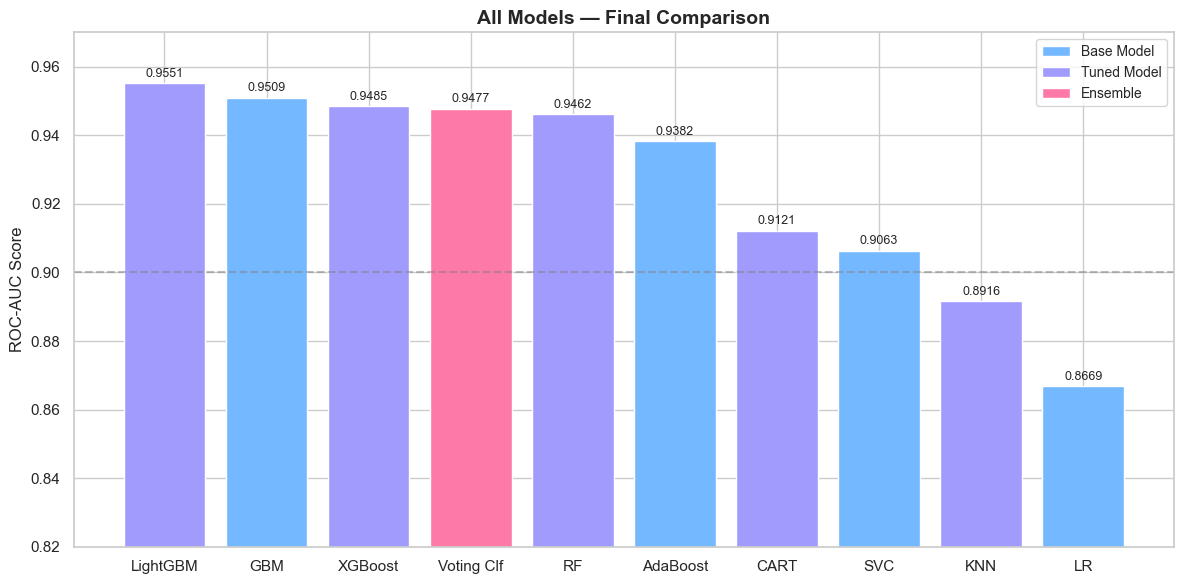


=== Final Summary ===

         Model  ROC-AUC      Type
1     LightGBM    0.955     Tuned
2          GBM    0.951      Base
3      XGBoost    0.949     Tuned
4   Voting Clf    0.948  Ensemble
5           RF    0.946     Tuned
6     AdaBoost    0.938      Base
7         CART    0.912     Tuned
8          SVC    0.906      Base
9          KNN    0.892     Tuned
10          LR    0.867      Base


In [23]:
summary = {
    "Model"    : ["LR", "KNN", "SVC", "CART", "RF", "AdaBoost", "GBM", "XGBoost", "LightGBM", "Voting Clf"],
    "ROC-AUC"  : [0.8669, 0.8916, 0.9063, 0.9121, 0.9462, 0.9382, 0.9509, 0.9485, 0.9551, 0.9477],
    "Type"     : ["Base", "Tuned", "Base", "Tuned", "Tuned", "Base", "Base", "Tuned", "Tuned", "Ensemble"]
}

summary_df = pd.DataFrame(summary).sort_values("ROC-AUC", ascending=False)
summary_df = summary_df.reset_index(drop=True)
summary_df.index += 1

colors_map = {"Base": "#74b9ff", "Tuned": "#a29bfe", "Ensemble": "#fd79a8"}

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = [colors_map[t] for t in summary_df["Type"]]
bars = ax.bar(summary_df["Model"], summary_df["ROC-AUC"],
              color=bar_colors, edgecolor="white")

ax.set_ylim(0.82, 0.97)
ax.set_ylabel("ROC-AUC Score", fontsize=12)
ax.set_title("All Models — Final Comparison", fontsize=14, fontweight="bold")
ax.axhline(y=0.90, color="gray", linestyle="--", alpha=0.5)

for bar, score in zip(bars, summary_df["ROC-AUC"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{score:.4f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#74b9ff", label="Base Model"),
    Patch(facecolor="#a29bfe", label="Tuned Model"),
    Patch(facecolor="#fd79a8", label="Ensemble"),
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

print("\n=== Final Summary ===\n")
print(summary_df.to_string(index=True))

---
## 📋 Final Results

| | Model | ROC-AUC |
|--|-------|---------|
| 🥇 | LightGBM (Tuned) | 0.9551 |
| 🥈 | GBM (Base) | 0.9509 |
| 🥉 | XGBoost (Tuned) | 0.9485 |
| 🏅 | Voting Classifier | 0.9477 |

### Key Takeaways
- **Glucose** is the single most correlated feature with diabetes
- **Feature engineering** improved results — NEW_INSULIN_BMI ranked 2nd in importance
- **Tree-based models** dominate this dataset
- **Voting Classifier** provides stable and reliable predictions

### Model saved
- `models/voting_clf.pkl`